In [2]:
import os
import kagglehub

path = kagglehub.dataset_download(
    "waseemalastal/breakhis-breast-cancer-histopathological-dataset"
)

print(path)

for root, dirs, files in os.walk(path):

    print(root)

    if len(files) > 0:
        print("Sample file:", files[0])

    print("-"*50)

Using Colab cache for faster access to the 'breakhis-breast-cancer-histopathological-dataset' dataset.
/kaggle/input/breakhis-breast-cancer-histopathological-dataset
/kaggle/input/breakhis-breast-cancer-histopathological-dataset
--------------------------------------------------
/kaggle/input/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database
--------------------------------------------------
/kaggle/input/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1
--------------------------------------------------
/kaggle/input/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1
--------------------------------------------------
/kaggle/input/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_mul

In [3]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# CONFIG
# ==========================================

import os
import kagglehub

root_path = kagglehub.dataset_download(
    "waseemalastal/breakhis-breast-cancer-histopathological-dataset"
)

DATASET_PATH = os.path.join(
    root_path,
    "BreakHis - Breast Cancer Histopathological Database",
    "dataset_cancer_v1",
    "dataset_cancer_v1",
    "classificacao_binaria"
)

print(DATASET_PATH)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
SEED = 42

tf.random.set_seed(SEED)

# ==========================================
# LOAD PATHS + LABELS
# ==========================================

image_paths = []
labels = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith((".png", ".jpg", ".jpeg")):

            full_path = os.path.join(root, file)

            if "benign" in root.lower():
                label = 0

            elif "malignant" in root.lower():
                label = 1

            else:
                continue

            image_paths.append(full_path)
            labels.append(label)

print(f"Total Images: {len(image_paths)}")

# ==========================================
# SPLIT DATA
# ==========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

# ==========================================
# CLASS WEIGHTS
# ==========================================

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print("Class Weights:", class_weights)

# ==========================================
# DATA PIPELINE
# ==========================================

AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

def build_dataset(paths, labels, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if training:
        ds = ds.shuffle(5000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = build_dataset(
    X_train,
    y_train,
    training=True
)

val_ds = build_dataset(
    X_val,
    y_val
)

test_ds = build_dataset(
    X_test,
    y_test
)

# ==========================================
# DATA AUGMENTATION
# ==========================================

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.10)
])

# ==========================================
# CNN MODEL
# ==========================================

inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = augmentation(inputs)

# Block 1
x = tf.keras.layers.Conv2D(
    32, 3,
    padding="same"
)(x)

x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D()(x)

# Block 2
x = tf.keras.layers.Conv2D(
    64, 3,
    padding="same"
)(x)

x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D()(x)

# Block 3
x = tf.keras.layers.Conv2D(
    128, 3,
    padding="same"
)(x)

x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D()(x)

# Block 4
x = tf.keras.layers.Conv2D(
    256, 3,
    padding="same"
)(x)

x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D()(x)

# Block 5
x = tf.keras.layers.Conv2D(
    512, 3,
    padding="same"
)(x)

x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    256,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.5)(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

# ==========================================
# COMPILE
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

# ==========================================
# CALLBACKS
# ==========================================

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=6,
        restore_best_weights=True,
        mode="max"
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_breakhis_cnn.keras",
        monitor="val_auc",
        save_best_only=True,
        mode="max"
    )
]

# ==========================================
# TRAIN
# ==========================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

# ==========================================
# TEST
# ==========================================

results = model.evaluate(test_ds)

print("\nTEST RESULTS")

for metric, value in zip(
    model.metrics_names,
    results
):
    print(f"{metric}: {value:.4f}")

# ==========================================
# SAVE
# ==========================================

model.save(
    "breakhis_final_model.keras"
)

Using Colab cache for faster access to the 'breakhis-breast-cancer-histopathological-dataset' dataset.
/kaggle/input/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_binaria
Total Images: 7909
Class Weights: {0: np.float64(1.5945060483870968), 1: np.float64(0.7284135390283214)}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 1,736,897 (6.63 MB)

 Trainable params: 1,734,913 (6.62 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 64s 169ms/step - accuracy: 0.8121 - auc: 0.8922 - loss: 0.4124 - precision: 0.8950 - recall: 0.8227 - val_accuracy: 0.6865 - val_auc: 0.5280 - val_loss: 1.2625 - val_precision: 0.6865 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 41s 161ms/step - accuracy: 0.8571 - auc: 0.9303 - loss: 0.3370 - precision: 0.9296 - recall: 0.8568 - val_accuracy: 0.6966 - val_auc: 0.7664 - val_loss: 1.1272 - val_precision: 0.6935 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 40s 155ms/step - accuracy: 0.8653 - auc: 0.9396 - loss: 0.3149 - precision: 0.9339 - recall: 0.8651 - val_accuracy: 0.7611 - val_auc: 0.9268 - val_loss: 0.4478 - val_precision: 0.7500 - val_recall: 0.9779 - learning_rate: 1.0000e-04
Epoch 4/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.8707 - auc: 0.9457 - loss: 0.2969 - precision: 0.9407 - recall: 0.8662 - val_accuracy: 0.6814 - val_auc: 0.9240 

In [5]:
model.save(
    "breakhis_final_model.keras"
)

In [6]:
print(model.metrics_names)
print(results)

['loss', 'compile_metrics']
[0.2589682936668396, 0.8912768363952637, 0.9782013297080994, 0.9978213310241699, 0.8434622287750244]


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step
Confusion Matrix:
[[247   1]
 [ 85 458]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.74      1.00      0.85       248
   Malignant       1.00      0.84      0.91       543

    accuracy                           0.89       791
   macro avg       0.87      0.92      0.88       791
weighted avg       0.92      0.89      0.89       791



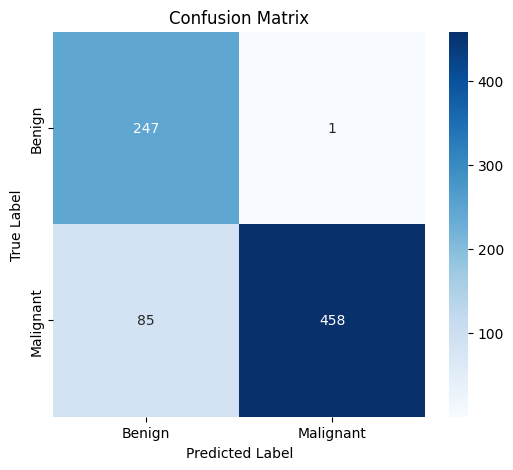

In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get true labels
y_true = np.concatenate(
    [y for _, y in test_ds],
    axis=0
)

# Get predicted probabilities
y_pred_probs = model.predict(test_ds)

# Convert probabilities to 0/1
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [8]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

Accuracy : 0.8912768647281921
Precision: 0.9978213507625272
Recall   : 0.8434622467771639
F1 Score : 0.9141716566866267


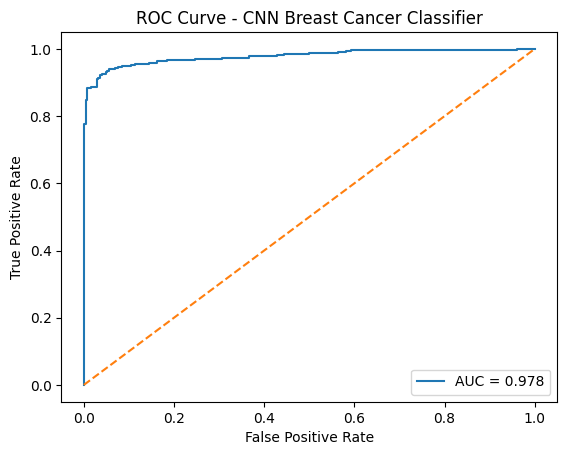

In [10]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# y_true = actual labels (0/1)
# y_pred_probs = model probabilities (not class labels!)

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN Breast Cancer Classifier')
plt.legend()
plt.show()

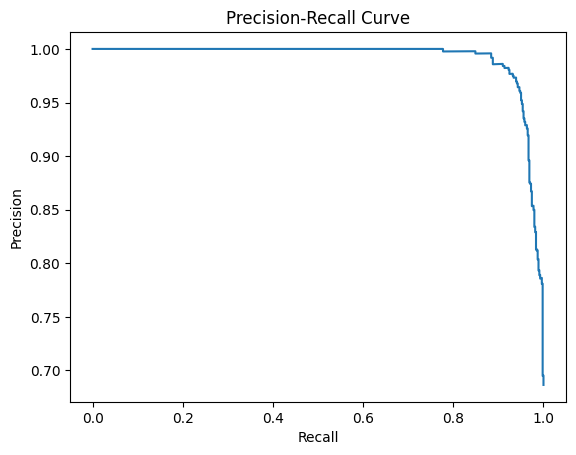

In [12]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, y_pred_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [14]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)

f1_scores = []

for t in thresholds:
    y_pred_t = (y_pred_probs >= t).astype(int)
    f1_scores.append(f1_score(y_true, y_pred_t))

best_t = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_t)
print("Best F1 Score:", max(f1_scores))

Best Threshold: 0.19999999999999996
Best F1 Score: 0.9550561797752809


In [15]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)   # recall for malignant
specificity = tn / (tn + fp)

print("Sensitivity (Cancer Detection Rate):", sensitivity)
print("Specificity (Healthy Detection Rate):", specificity)

Sensitivity (Cancer Detection Rate): 0.8434622467771639
Specificity (Healthy Detection Rate): 0.9959677419354839
